In [2]:
import sys
import os

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
adata = sc.read_h5ad("../../../../results/multi_subspace/all_cells/01_13_before_early_stopping/r2, e2, e2, e10_all_encode_v63_z_params_best_with_clusters.h5ad")

In [5]:
sc.tl.rank_genes_groups(
adata,
groupby="kmeans_cluster",
method="wilcoxon", # robust default
use_raw=True # if you stored raw counts in adata.raw
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/scanpy_umap/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


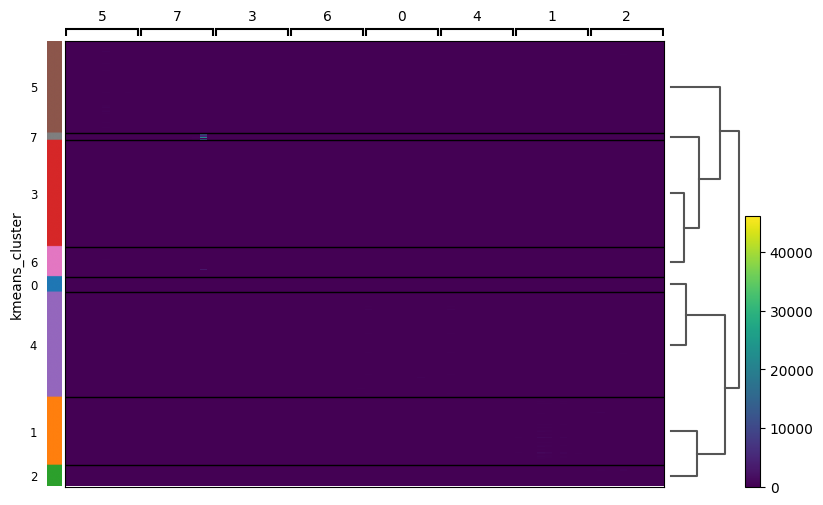

In [15]:
sc.pl.rank_genes_groups_heatmap(
adata,
groupby="kmeans_cluster",
n_genes=10,
show=True
)

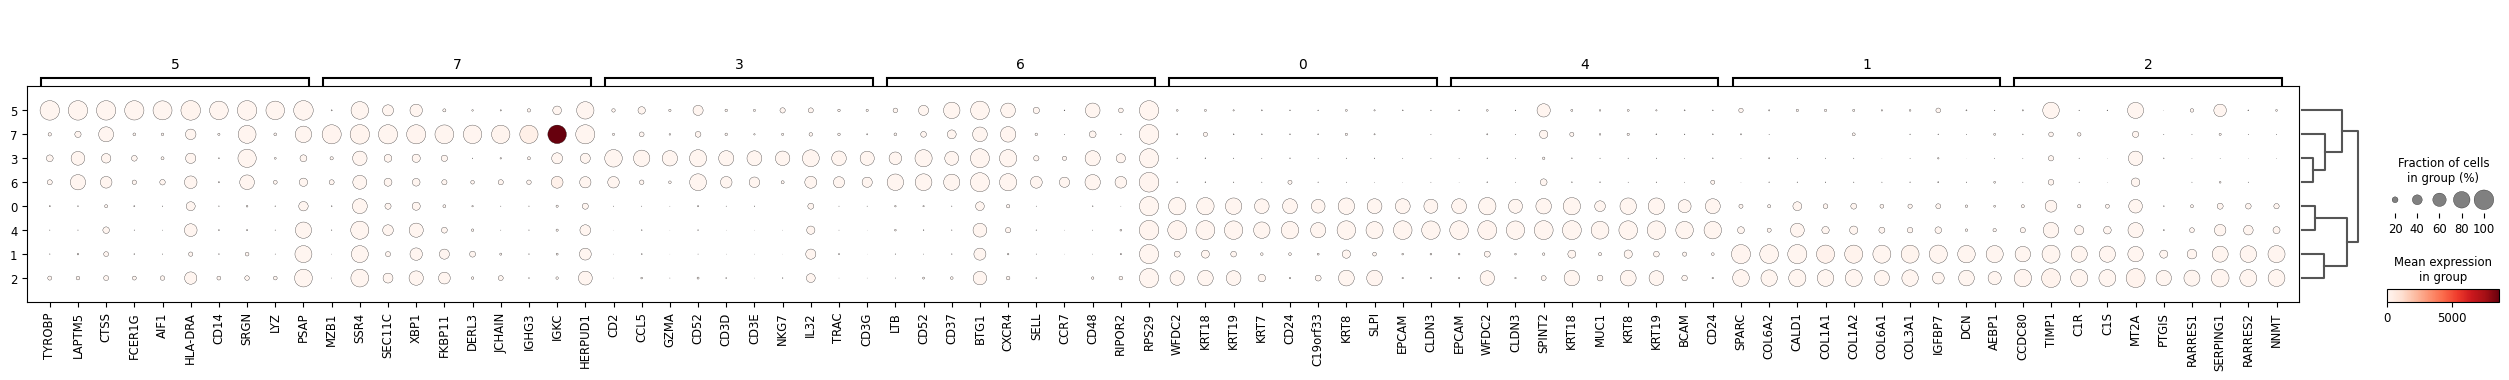

In [16]:
sc.pl.rank_genes_groups_dotplot(
adata,
groupby="kmeans_cluster",
n_genes=10
)

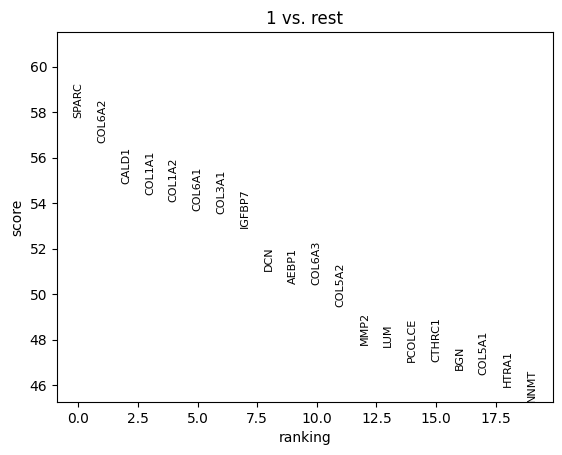

In [17]:
sc.pl.rank_genes_groups(
adata,
groups=["1"],
n_genes=20
)

In [12]:
for cluster in adata.obs["kmeans_cluster"].unique():
    print(f"Distribution of Cell Types for Cluster {cluster}")
    print(adata.obs["cell_type"][adata.obs["kmeans_cluster"] == cluster].value_counts())
    print("\n")

Distribution of Cell Types for Cluster 3
cell_type
T cell                                      2385
B cell                                        16
plasma cell                                    9
fallopian tube secretory epithelial cell       9
monocyte                                       9
mast cell                                      3
fibroblast                                     0
endothelial cell                               0
dendritic cell                                 0
Name: count, dtype: int64


Distribution of Cell Types for Cluster 4
cell_type
fallopian tube secretory epithelial cell    2336
fibroblast                                    51
endothelial cell                               5
plasma cell                                    4
B cell                                         3
monocyte                                       2
T cell                                         1
mast cell                                      1
dendritic cell                       

**Fibroblast clusters are clusters 1 and 2**

In [13]:
sc.get.rank_genes_groups_df(
adata,
group="1"
).head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,SPARC,57.767742,48.839222,0.0,0.0
1,COL6A2,56.636887,23.012766,0.0,0.0
2,CALD1,54.835339,23.743120,0.0,0.0
3,COL1A1,54.374187,196.535431,0.0,0.0
4,COL1A2,54.072842,146.755203,0.0,0.0
5,COL6A1,53.659271,26.124805,0.0,0.0
6,COL3A1,53.529278,107.953331,0.0,0.0
7,IGFBP7,52.911995,22.204618,0.0,0.0
8,DCN,51.040703,25.506876,0.0,0.0
9,AEBP1,50.437771,13.157807,0.0,0.0


In [14]:
sc.get.rank_genes_groups_df(
adata,
group="2"
).head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CCDC80,29.649031,65.105469,3.490467e-193,1.110492e-188
1,TIMP1,29.054291,141.711258,1.358284e-185,2.160691e-181
2,C1R,27.889347,18.133514,3.592641e-171,3.809996e-167
3,C1S,26.617254,13.120524,4.286319e-156,3.409231e-152
4,MT2A,25.701878,149.197800,1.113717e-145,7.086581e-142
5,PTGIS,25.596083,9.817929,1.686680e-144,8.943618e-141
6,RARRES1,25.508165,12.471607,1.600151e-143,7.272685e-140
7,SERPING1,25.167021,9.487822,9.203131e-140,3.659970e-136
8,RARRES2,25.035219,19.924143,2.529411e-138,8.941469e-135
9,NNMT,24.828005,12.454556,4.469432e-136,1.421950e-132


#### Analyzing Genes 1-by-1 (Top 10 Analysis)

**Method: The NCBI Gene Summaries for Each Gene was copied from genecards.org**

**Cluster 1:**

SPARC: 

This gene encodes a cysteine-rich acidic matrix-associated protein. The encoded protein is required for the collagen in bone to become calcified but is also involved in extracellular matrix synthesis and promotion of changes to cell shape. The gene product has been associated with tumor suppression but has also been correlated with metastasis based on changes to cell shape which can promote tumor cell invasion. Three transcript variants encoding different isoforms have been found for this gene.

COL6A2: 

This gene encodes one of the three alpha chains of type VI collagen, a beaded filament collagen found in most connective tissues. The product of this gene contains several domains similar to von Willebrand Factor type A domains. These domains have been shown to bind extracellular matrix proteins, an interaction that explains the importance of this collagen in organizing matrix components. Mutations in this gene are associated with Bethlem myopathy and Ullrich scleroatonic muscular dystrophy. Three transcript variants have been identified for this gene.

CALD1:

This gene encodes a calmodulin- and actin-binding protein that plays an essential role in the regulation of smooth muscle and nonmuscle contraction. The conserved domain of this protein possesses the binding activities to Ca(2+)-calmodulin, actin, tropomyosin, myosin, and phospholipids. This protein is a potent inhibitor of the actin-tropomyosin activated myosin MgATPase, and serves as a mediating factor for Ca(2+)-dependent inhibition of smooth muscle contraction. Alternative splicing of this gene results in multiple transcript variants encoding distinct isoforms. 

COL1A1:

This gene encodes the pro-alpha1 chains of type I collagen whose triple helix comprises two alpha1 chains and one alpha2 chain. Type I is a fibril-forming collagen found in most connective tissues and is abundant in bone, cornea, dermis and tendon. Mutations in this gene are associated with osteogenesis imperfecta types I-IV, Ehlers-Danlos syndrome type VIIA, Ehlers-Danlos syndrome Classical type, Caffey Disease and idiopathic osteoporosis. Reciprocal translocations between chromosomes 17 and 22, where this gene and the gene for platelet-derived growth factor beta are located, are associated with a particular type of skin tumor called dermatofibrosarcoma protuberans, resulting from unregulated expression of the growth factor. Two transcripts, resulting from the use of alternate polyadenylation signals, have been identified for this gene. [provided by R. Dalgleish, Feb 2008]

COL1A2:

This gene encodes the pro-alpha2 chain of type I collagen whose triple helix comprises two alpha1 chains and one alpha2 chain. Type I is a fibril-forming collagen found in most connective tissues and is abundant in bone, cornea, dermis and tendon. Mutations in this gene are associated with osteogenesis imperfecta types I-IV, Ehlers-Danlos syndrome type VIIB, recessive Ehlers-Danlos syndrome Classical type, idiopathic osteoporosis, and atypical Marfan syndrome. Symptoms associated with mutations in this gene, however, tend to be less severe than mutations in the gene for the alpha1 chain of type I collagen (COL1A1) reflecting the different role of alpha2 chains in matrix integrity. Three transcripts, resulting from the use of alternate polyadenylation signals, have been identified for this gene. 

COL6A1:

The collagens are a superfamily of proteins that play a role in maintaining the integrity of various tissues. Collagens are extracellular matrix proteins and have a triple-helical domain as their common structural element. Collagen VI is a major structural component of microfibrils. The basic structural unit of collagen VI is a heterotrimer of the alpha1(VI), alpha2(VI), and alpha3(VI) chains. The alpha2(VI) and alpha3(VI) chains are encoded by the COL6A2 and COL6A3 genes, respectively. The protein encoded by this gene is the alpha 1 subunit of type VI collagen (alpha1(VI) chain). Mutations in the genes that code for the collagen VI subunits result in the autosomal dominant disorder, Bethlem myopathy. [provided by RefSeq, Jul 2008]

COL3A1:

This gene encodes the pro-alpha1 chains of type III collagen, a fibrillar collagen that is found in extensible connective tissues such as skin, lung, uterus, intestine and the vascular system, frequently in association with type I collagen. Mutations in this gene are associated with Ehlers-Danlos syndrome type IV, and with aortic and arterial aneurysms. 

IGFBP7:

This gene encodes a member of the insulin-like growth factor (IGF)-binding protein (IGFBP) family. IGFBPs bind IGFs with high affinity, and regulate IGF availability in body fluids and tissues and modulate IGF binding to its receptors. This protein binds IGF-I and IGF-II with relatively low affinity, and belongs to a subfamily of low-affinity IGFBPs. It also stimulates prostacyclin production and cell adhesion. Alternatively spliced transcript variants encoding different isoforms have been described for this gene, and one variant has been associated with retinal arterial macroaneurysm (PMID:21835307). 

DCN:

This gene encodes a member of the small leucine-rich proteoglycan family of proteins. Alternative splicing results in multiple transcript variants, at least one of which encodes a preproprotein that is proteolytically processed to generate the mature protein. This protein plays a role in collagen fibril assembly. Binding of this protein to multiple cell surface receptors mediates its role in tumor suppression, including a stimulatory effect on autophagy and inflammation and an inhibitory effect on angiogenesis and tumorigenesis. This gene and the related gene biglycan are thought to be the result of a gene duplication. Mutations in this gene are associated with congenital stromal corneal dystrophy in human patients. 

AEBP1:

This gene encodes a member of carboxypeptidase A protein family. The encoded protein may function as a transcriptional repressor and play a role in adipogenesis and smooth muscle cell differentiation. Studies in mice suggest that this gene functions in wound healing and abdominal wall development. Overexpression of this gene is associated with glioblastoma.

**Cluster 2:**

CCDC80:

Predicted to enable fibronectin binding activity and heparin binding activity. Predicted to be involved in extracellular matrix organization and positive regulation of cell-substrate adhesion. Predicted to act upstream of or within response to bacterium. Predicted to be located in extracellular region; interstitial matrix; and membrane. Predicted to be active in basement membrane.

TIMP1:

This gene belongs to the TIMP gene family. The proteins encoded by this gene family are natural inhibitors of the matrix metalloproteinases (MMPs), a group of peptidases involved in degradation of the extracellular matrix. In addition to its inhibitory role against most of the known MMPs, the encoded protein is able to promote cell proliferation in a wide range of cell types, and may also have an anti-apoptotic function. Transcription of this gene is highly inducible in response to many cytokines and hormones. In addition, the expression from some but not all inactive X chromosomes suggests that this gene inactivation is polymorphic in human females. This gene is located within intron 6 of the synapsin I gene and is transcribed in the opposite direction.

C1R:

This gene encodes a member of the peptidase S1 protein family. The encoded protein is a proteolytic subunit in the complement system C1 complex. The complement system acts as a mediator in the innate immune response by ultimately triggering phagocytosis, inflammation, and rupturing the bacterial cell wall. Mutations in this gene are associated with Ehlers-Danlos Syndrome.

C1S:

This gene encodes a serine protease, which is a major constituent of the human complement subcomponent C1. C1s associates with two other complement components C1r and C1q in order to yield the first component of the serum complement system. Defects in this gene are the cause of selective C1s deficiency.

MT2A:

This gene is a member of the metallothionein family of genes. Proteins encoded by this gene family are low in molecular weight, are cysteine-rich, lack aromatic residues, and bind divalent heavy metal ions, altering the intracellular concentration of heavy metals in the cell. These proteins act as anti-oxidants, protect against hydroxyl free radicals, are important in homeostatic control of metal in the cell, and play a role in detoxification of heavy metals. The encoded protein interacts with the protein encoded by the homeobox containing 1 gene in some cell types, controlling intracellular zinc levels, affecting apoptotic and autophagy pathways. Some polymorphisms in this gene are associated with an increased risk of cancer.

PTGIS:

This gene encodes a member of the cytochrome P450 superfamily of enzymes. The cytochrome P450 proteins are monooxygenases which catalyze many reactions involved in drug metabolism and synthesis of cholesterol, steroids and other lipids. However, this protein is considered a member of the cytochrome P450 superfamily on the basis of sequence similarity rather than functional similarity. This endoplasmic reticulum membrane protein catalyzes the conversion of prostglandin H2 to prostacyclin (prostaglandin I2), a potent vasodilator and inhibitor of platelet aggregation. An imbalance of prostacyclin and its physiological antagonist thromboxane A2 contribute to the development of myocardial infarction, stroke, and atherosclerosis

RARRES1:

This gene was identified as a retinoid acid (RA) receptor-responsive gene. It encodes a type 1 membrane protein. The expression of this gene is upregulated by tazarotene as well as by retinoic acid receptors. The expression of this gene is found to be downregulated in prostate cancer, which is caused by the methylation of its promoter and CpG island. Alternatively spliced transcript variant encoding distinct isoforms have been observed.

SERPING1:

This gene encodes a highly glycosylated plasma protein involved in the regulation of the complement cascade. Its encoded protein, C1 inhibitor, inhibits activated C1r and C1s of the first complement component and thus regulates complement activation. It is synthesized in the liver, and its deficiency is associated with hereditary angioneurotic oedema (HANE). Alternative splicing results in multiple transcript variants encoding the same isoform.

RARRES2:

This gene encodes a secreted chemotactic protein that initiates chemotaxis via the ChemR23 G protein-coupled seven-transmembrane domain ligand. Expression of this gene is upregulated by the synthetic retinoid tazarotene and occurs in a wide variety of tissues. The active protein has several roles, including that as an adipokine and as an antimicrobial protein with activity against bacteria and fungi.

NNMT:

N-methylation is one method by which drug and other xenobiotic compounds are metabolized by the liver. This gene encodes the protein responsible for this enzymatic activity which uses S-adenosyl methionine as the methyl donor. 


#### Analyzing Genes in Aggregate (GSEA) Analysis with mSigDB

**Cluster 1**

In [43]:
de_genes_1 = sc.get.rank_genes_groups_df(
adata,
group="1"
)

In [44]:
rnk_1 = de_genes_1[['names', 'logfoldchanges']].set_index('names')['logfoldchanges']
rnk_1 = rnk_1.sort_values(ascending=False) # most upregulated first
# TODO: does it make logical sense to place our most upregulated genes first in our 
#       dataframe?

In [45]:
hallmark_gene_sets_path = "../../../../genes/gene_sets/mSigDB/h.all.v2025.1.Hs.symbols.gmt"

In [52]:
import gseapy as gp

gsea_res_1 = gp.prerank(
rnk=rnk_1,
gene_sets=hallmark_gene_sets_path, # Hallmark gene sets
outdir='gsea_results_cluster1',
seed=0
)

# top enriched pathways
print(gsea_res_1.res2d)

2026-01-24 18:37:51,989 [WARNING] Duplicated values found in preranked stats: 48.90% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


       Name                                        Term        ES       NES  \
0   prerank                     HALLMARK_UV_RESPONSE_DN   0.78409   2.20845   
1   prerank                       HALLMARK_ANGIOGENESIS  0.623569  1.484695   
2   prerank                HALLMARK_ALLOGRAFT_REJECTION -0.674214 -1.169185   
3   prerank            HALLMARK_IL6_JAK_STAT3_SIGNALING -0.596953 -1.019727   
4   prerank              HALLMARK_INFLAMMATORY_RESPONSE -0.583417 -1.008669   
5   prerank                  HALLMARK_KRAS_SIGNALING_DN -0.579742 -1.000682   
6   prerank                         HALLMARK_MYOGENESIS  0.501815       1.0   
7   prerank  HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION  0.823675       1.0   
8   prerank                    HALLMARK_NOTCH_SIGNALING  0.422937  0.999982   
9   prerank                    HALLMARK_SPERMATOGENESIS -0.568325 -0.974084   
10  prerank    HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY -0.572573 -0.967698   
11  prerank                 HALLMARK_TGF_BETA_SIGNAL

In [53]:
print(gsea_res_1.res2d.head())

      Name                              Term        ES       NES NOM p-val  \
0  prerank           HALLMARK_UV_RESPONSE_DN   0.78409   2.20845       0.0   
1  prerank             HALLMARK_ANGIOGENESIS  0.623569  1.484695  0.105263   
2  prerank      HALLMARK_ALLOGRAFT_REJECTION -0.674214 -1.169185     0.003   
3  prerank  HALLMARK_IL6_JAK_STAT3_SIGNALING -0.596953 -1.019727  0.468876   
4  prerank    HALLMARK_INFLAMMATORY_RESPONSE -0.583417 -1.008669     0.478   

  FDR q-val FWER p-val    Tag %  Gene %  \
0       0.0        0.0   38/144   8.47%   
1  0.110759      0.005     8/36   3.04%   
2       1.0      0.799  108/200  23.02%   
3       1.0        1.0    35/87  24.44%   
4       1.0        1.0   92/200  25.43%   

                                          Lead_genes  
0  COL1A1;COL1A2;COL3A1;COL5A2;COL11A1;PDGFRB;IGF...  
1   COL3A1;LUM;POSTN;COL5A2;VCAN;FSTL1;SLCO2A1;KCNJ8  
2  HLA-DRA;CD74;B2M;CD8A;CCR5;SIT1;TRAT1;IRF4;MAP...  
3  PIK3R5;IL9R;CSF2;DNTT;INHBE;CRLF2;IL1B;CD14;IL...

**Cluster 2**

In [47]:
de_genes_2 = sc.get.rank_genes_groups_df(
adata,
group="2"
)

In [48]:
rnk_2 = de_genes_2[['names', 'logfoldchanges']].set_index('names')['logfoldchanges']
rnk_2 = rnk_2.sort_values(ascending=False) # most upregulated first
# TODO: does it make logical sense to place our most upregulated genes first in our 
#       dataframe?

In [49]:
rnk_2

names
MALAT1    156.954071
MT2A      149.197800
TIMP1     141.711258
FTH1      100.801643
CCDC80     65.105469
             ...    
MT-CO2    -48.192070
IGLC3     -49.549412
MT-CO1    -52.679955
IGLC2     -75.483940
IGKC     -239.779221
Name: logfoldchanges, Length: 31815, dtype: float32

In [54]:
import gseapy as gp

gsea_res_2 = gp.prerank(
rnk=rnk_2,
gene_sets=hallmark_gene_sets_path, # Hallmark gene sets
outdir='gsea_results_cluster2',
seed=0
)

# top enriched pathways
print(gsea_res_2.res2d)

2026-01-24 18:37:55,966 [WARNING] Duplicated values found in preranked stats: 52.78% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


       Name                                        Term        ES       NES  \
0   prerank                       HALLMARK_ANGIOGENESIS   0.75154  1.440476   
1   prerank                 HALLMARK_TGF_BETA_SIGNALING  0.558015   1.23812   
2   prerank                HALLMARK_PANCREAS_BETA_CELLS -0.656775 -1.043683   
3   prerank                  HALLMARK_ANDROGEN_RESPONSE  0.389933       1.0   
4   prerank            HALLMARK_ESTROGEN_RESPONSE_EARLY    0.2686       1.0   
5   prerank                     HALLMARK_MYC_TARGETS_V1  0.465613       1.0   
6   prerank              HALLMARK_XENOBIOTIC_METABOLISM  0.339614       1.0   
7   prerank                         HALLMARK_GLYCOLYSIS  0.325641       1.0   
8   prerank                  HALLMARK_PROTEIN_SECRETION  0.449479       1.0   
9   prerank                        HALLMARK_P53_PATHWAY  0.323586       1.0   
10  prerank          HALLMARK_UNFOLDED_PROTEIN_RESPONSE  0.590419       1.0   
11  prerank                   HALLMARK_MTORC1_SIGNAL

In [55]:
print(gsea_res_2.res2d.head())

      Name                              Term        ES       NES NOM p-val  \
0  prerank             HALLMARK_ANGIOGENESIS   0.75154  1.440476       0.0   
1  prerank       HALLMARK_TGF_BETA_SIGNALING  0.558015   1.23812       0.0   
2  prerank      HALLMARK_PANCREAS_BETA_CELLS -0.656775 -1.043683   0.38593   
3  prerank        HALLMARK_ANDROGEN_RESPONSE  0.389933       1.0       1.0   
4  prerank  HALLMARK_ESTROGEN_RESPONSE_EARLY    0.2686       1.0       1.0   

  FDR q-val FWER p-val   Tag %  Gene %  \
0       0.0        0.0    9/36   3.51%   
1       1.0      0.005   14/54   9.73%   
2       1.0        1.0   15/40  26.07%   
3  0.555833      0.021  28/100  10.69%   
4  0.555833      0.021  47/200  10.35%   

                                          Lead_genes  
0  TIMP1;COL3A1;LUM;CXCL6;VTN;STC1;VEGFA;FSTL1;TN...  
1  SERPINE1;BMP2;NOG;SPTBN1;BCAR3;ID2;ID1;CDKN1C;...  
2  CHGA;FOXA2;SYT13;PAX6;NKX6-1;PCSK2;PKLR;IAPP;I...  
3  B2M;SAT1;KRT19;KRT8;ALDH1A3;SELENOP;LMAN1;NDRG...  
4  

**Q: Could gene expression differences in the two fibroblast clusters be due to locaiton?**

In [57]:
adata.obs.columns

Index(['percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score',
       'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA',
       'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id',
       'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type',
       'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'donor_id', 'author_tumor_supersite', 'author_tumor_site',
       'author_tumor_subsite', 'author_sort_parameters', 'author_therapy',
       'author_procedure', 'author_procedure_type', 'is_primary_data',
       'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'development_stage', 'observation_joinid',
       'interferon_score', 'dissociation_score', 'batch', 'kmeans_cluster'],
      dtype='object')

In [59]:
adata.obs["tissue"].unique()

['ascitic fluid', 'left ovary', 'omentum', 'adnexa of uterus', 'fallopian tube', ..., 'lymph node', 'liver', 'urinary bladder', 'parietal peritoneum', 'paracolic gutter']
Length: 19
Categories (19, object): ['lymph node', 'large intestine', 'intestine', 'abdomen', ..., 'fallopian tube', 'ascitic fluid', 'paracolic gutter', 'adnexa of uterus']

In [78]:
mask_kmeans_1 = adata.obs["kmeans_cluster"] == "1"  
mask_kmeans_2 = adata.obs["kmeans_cluster"] == "2"
mask_fibroblast = adata.obs["cell_type"] == "fibroblast"

In [85]:
adata[mask_kmeans_1.values].obs["tissue"].value_counts()

tissue
omentum                423
adnexa of uterus       256
right ovary            161
left ovary             157
intestine              103
peritoneum              98
diaphragm               68
transverse colon        57
parietal peritoneum     52
liver                   38
abdomen                 33
caecum                  28
large intestine         25
paracolic gutter        25
fallopian tube          22
ascitic fluid            6
urinary bladder          2
lymph node               2
Name: count, dtype: int64

In [93]:
adata[mask_kmeans_1 & mask_fibroblast].obs["tissue"].value_counts()

tissue
omentum                356
adnexa of uterus       221
right ovary            151
left ovary             140
peritoneum              95
intestine               88
diaphragm               57
transverse colon        55
parietal peritoneum     44
liver                   32
abdomen                 29
caecum                  26
paracolic gutter        25
large intestine         21
fallopian tube          17
ascitic fluid            3
urinary bladder          2
Name: count, dtype: int64

In [75]:
adata[mask_kmeans_2].obs["tissue"].value_counts()

tissue
ascitic fluid          152
omentum                 85
urinary bladder         67
adnexa of uterus        52
peritoneum              42
diaphragm               25
left ovary              15
right ovary             14
intestine               13
abdomen                  8
large intestine          6
fallopian tube           3
caecum                   2
parietal peritoneum      2
transverse colon         1
Name: count, dtype: int64

In [94]:
adata[mask_kmeans_2 & mask_fibroblast].obs["tissue"].value_counts()

tissue
ascitic fluid          152
omentum                 76
urinary bladder         62
adnexa of uterus        36
peritoneum              26
diaphragm               24
right ovary             10
left ovary               7
large intestine          6
intestine                6
abdomen                  5
caecum                   2
parietal peritoneum      1
fallopian tube           1
Name: count, dtype: int64